# Step 1: Clone

In [1]:
from __future__ import annotations
import csv, os, re, subprocess, time
from pathlib import Path
from typing import Optional, List

# -----------------------------
# Config (edit as needed)
# -----------------------------
WORK_ROOT    = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2")
URL_LIST_CSV = WORK_ROOT / "URL_List.csv"
CLONE_ROOT   = WORK_ROOT / "clonesV8.1"
MANIFEST_CSV = WORK_ROOT / "clones_manifestV8.1.csv"

WITH_SUBMODULES = False     # set True if you want submodules initialized/updated
WITH_LFS        = False     # set True if you need Git LFS objects
FETCH_PR_REFS   = True      # set False to skip GitHub PR heads

# Create dirs
WORK_ROOT.mkdir(parents=True, exist_ok=True)
CLONE_ROOT.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
DEFAULT_TIMEOUT = 1800  # 30 minutes for huge repos
GIT_ENV = {"GIT_TERMINAL_PROMPT": "0", "GIT_ASKPASS": ""}

def sh(cmd: List[str], cwd: Optional[Path] = None, check: bool = True,
       capture: bool = True, timeout: Optional[int] = DEFAULT_TIMEOUT) -> subprocess.CompletedProcess:
    env = os.environ.copy()
    env.update(GIT_ENV)
    return subprocess.run(cmd, cwd=cwd, check=check,
                          capture_output=capture, text=True,
                          timeout=timeout, env=env)

def sh_ok(cmd: List[str], cwd: Optional[Path] = None, timeout: Optional[int] = DEFAULT_TIMEOUT) -> str:
    cp = sh(cmd, cwd=cwd, check=True, capture=True, timeout=timeout)
    return cp.stdout

def repo_dir_name_from_url(url: str) -> str:
    u = url.strip()
    # SSH form: git@host:owner/repo(.git)
    m = re.match(r"^[^@]+@([^:]+):([^/]+)/(.+?)(?:\.git)?$", u)
    if m:
        owner, name = m.group(2), m.group(3)
        return f"{owner}__{name}"
    # https://host/owner/repo(.git)
    if "://" in u:
        base = u.split("://", 1)[1]
    else:
        base = u
    parts = [p for p in base.split("/") if p]
    if len(parts) >= 2:
        owner, name = parts[-2], parts[-1].removesuffix(".git")
        return f"{owner}__{name}"
    return base.replace("/", "__").removesuffix(".git")

def ensure_full_clone(url: str, dest_root: Path,
                      with_submodules: bool = False,
                      with_lfs: bool = False,
                      fetch_pr_refs: bool = True) -> Path:
    """
    Ensures a non-shallow clone with full history of all branches & tags.
    Optionally fetches GitHub PR heads to refs/remotes/origin/pr/*,
    initializes submodules, and fetches LFS objects.
    """
    dest_root.mkdir(parents=True, exist_ok=True)
    d = dest_root / repo_dir_name_from_url(url)

    if not (d.exists() and (d / ".git").exists()):
        # no-recurse-submodules avoids submodule cost unless requested later
        sh(["git", "clone", "--no-recurse-submodules", "--tags", url, str(d)],
           capture=False)
    else:
        # If repo exists, ensure origin URL is correct
        sh(["git", "remote", "set-url", "origin", url], cwd=d, check=False)

    # If shallow, unshallow
    cp = sh(["git", "rev-parse", "--is-shallow-repository"], cwd=d, check=False)
    if cp.returncode == 0 and cp.stdout.strip() == "true":
        sh(["git", "fetch", "--unshallow", "--tags"], cwd=d, capture=False)
    else:
        # Make sure we have tags even if already full
        sh(["git", "fetch", "--tags"], cwd=d, check=False, capture=False)

    # Fetch all branches under refs/heads/* and prune deleted ones
    sh(["git", "fetch", "origin", "--prune", "--tags",
        "+refs/heads/*:refs/remotes/origin/*", "--quiet"], cwd=d, check=False, capture=False)

    # Best-effort PR refs (GitHub); harmless if not present
    if fetch_pr_refs:
        sh(["git", "fetch", "origin",
            "+refs/pull/*/head:refs/remotes/origin/pr/*", "--quiet"], cwd=d, check=False, capture=False)

    # Optional: submodules
    if with_submodules:
        sh(["git", "submodule", "update", "--init", "--recursive"], cwd=d, capture=False)

    # Optional: LFS
    if with_lfs:
        # If git-lfs isn't installed, these will fail harmlessly due to check=False
        sh(["git", "lfs", "install"], cwd=d, check=False, capture=False)
        sh(["git", "lfs", "fetch", "--all"], cwd=d, check=False, capture=False)
        sh(["git", "lfs", "checkout"], cwd=d, check=False, capture=False)

    return d

def get_total_commits(repo_dir: Path) -> int:
    # Count across all refs reachable in the repository
    cp = sh(["git", "rev-list", "--all", "--count"], cwd=repo_dir, check=False)
    try:
        return int((cp.stdout or "0").strip() or "0")
    except Exception:
        return 0

# -----------------------------
# Main: FULL CLONE ONLY
# -----------------------------
assert URL_LIST_CSV.exists(), f"CSV not found: {URL_LIST_CSV}"

rows, ok, fail = [], 0, 0
with URL_LIST_CSV.open(newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        url = (row.get("repo_url") or "").strip()
        if not url:
            continue
        t0 = time.time()
        rec = {
            "repo_url": url,
            "dir": None,
            "status": "unknown",
            "seconds": None,
            "total_commits": None,
            "error": ""
        }
        try:
            d = ensure_full_clone(url, CLONE_ROOT,
                                  with_submodules=WITH_SUBMODULES,
                                  with_lfs=WITH_LFS,
                                  fetch_pr_refs=FETCH_PR_REFS)
            rec["dir"] = str(d)
            rec["total_commits"] = get_total_commits(d)
            rec["status"] = "ok"
            ok += 1
        except subprocess.CalledProcessError as e:
            rec["status"] = "error"
            rec["error"]  = (e.stderr or e.stdout or str(e)).strip()[:2000]
            fail += 1
        except Exception as e:
            rec["status"] = "error"
            rec["error"]  = str(e)[:2000]
            fail += 1

        rec["seconds"] = round(time.time() - t0, 2)
        rows.append(rec)
        print(f"[{rec['status']}] {url} -> {rec['dir']} ({rec['seconds']}s)  commits={rec['total_commits']}")

# Write manifest
MANIFEST_CSV.parent.mkdir(parents=True, exist_ok=True)
fieldnames = ["repo_url","dir","status","seconds","total_commits","error"]
with MANIFEST_CSV.open("w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(rows)

print(f"\nDone. OK={ok}, FAIL={fail}. Manifest: {MANIFEST_CSV}")


[ok] https://github.com/Rajawali/Rajawali -> C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\clonesV8.1\Rajawali__Rajawali (19.6s)  commits=3065
[ok] https://github.com/splitwise/TokenAutoComplete -> C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\clonesV8.1\splitwise__TokenAutoComplete (1.65s)  commits=428
[ok] https://github.com/OpnTec/bodyapps-android -> C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\clonesV8.1\OpnTec__bodyapps-android (2.02s)  commits=160
[ok] https://github.com/Stuart-campbell/RushOrm -> C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\clonesV8.1\Stuart-campbell__RushOrm (1.48s)  commits=216
[ok] https://github.com/kost/NetworkMapper -> C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\clonesV8.1\kost__NetworkMapper (1.09s)  commits=71
[ok] https://github.com/Redgram/redgram-for-reddit -> C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\clonesV8.1\Redgram__redgram-for-reddit (1.95s)  commits=328
[ok] https://githu

## Step 2: Mining 
add a baseline to read the repos from the begining not from the first change

In [3]:
# miner_emulator_timeline_patched.py
# Step 2 (FAST, THREADS): timeline miner — Commit-snapshot scan with blob cache
# Implements: GMD = (Gradle DSL has GMD) AND (YAML calls GMD). No INTENT_GMD in outputs.

import json
import os
import re
import subprocess
import sys
from concurrent.futures import ThreadPoolExecutor as PoolExecutor, as_completed
from datetime import datetime
from functools import lru_cache
from pathlib import Path
from typing import Dict, List, Optional, Set, Tuple
import time
import random

# ---------------------------
# Config (edit as needed)
# ---------------------------
BASE_FOLDER   = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2")
INPUT_CLONES  = BASE_FOLDER / "clones"      # <-- your clones folder
OUTPUT_MINE   = BASE_FOLDER / "mineV3.0"    # <-- output JSONs

# Git cutoff (ISO). Git understands "--before".
CUTOFF_DEFAULT = "2025-08-10T23:59:59"

# Limit number of repos for testing; 0 = no limit
MAX_REPOS = 0

# Speed knobs
SKIP_MERGE_COMMITS = False           # merges can introduce styles; keep False
BLOB_MAX_SIZE = 800_000              # bytes; gate huge files
MAX_WORKERS = min(32, (os.cpu_count() or 8) * 2)
RESUME_IF_EXISTS = True              # skip repos with an existing output JSON
YAML_CI_FIRST = False                # scan all YAML, not just hotspots

# ---------------------------
# File type helpers
# ---------------------------
YAML_EXTS = (".yml", ".yaml")
GRADLE_NAMES = {
    "build.gradle",
    "build.gradle.kts",
    "settings.gradle",
    "settings.gradle.kts",
}
GRADLE_EXTS = (".gradle", ".gradle.kts")

SCRIPT_EXTS = (".sh", ".bat", ".cmd", ".ps1")
CI_BUILD_SPECIAL = {
    "Jenkinsfile",
    ".travis.yml",
    "azure-pipelines.yml",
    ".gitlab-ci.yml",
    "circle.yml",
}
XML_BUILD_FILES = {
    "pom.xml",
    "build.xml",
    "config.xml",
}

def is_yaml(path: str) -> bool:
    return os.path.splitext(path)[1].lower() in YAML_EXTS or os.path.basename(path) in CI_BUILD_SPECIAL

def is_gradle(path: str) -> bool:
    name = os.path.basename(path)
    ext = os.path.splitext(path)[1].lower()
    return name in GRADLE_NAMES or ext in GRADLE_EXTS

def is_script(path: str) -> bool:
    ext = os.path.splitext(path)[1].lower()
    base = os.path.basename(path)
    return ext in SCRIPT_EXTS or base in ("Jenkinsfile",)

def is_ci_xml_or_build_xml(path: str) -> bool:
    base = os.path.basename(path).lower()
    return base in {n.lower() for n in XML_BUILD_FILES}

def is_relevant_file(path: str) -> bool:
    # YAML/Gradle are relevant to GMD/GENERIC/DIY; scripts/XML relevant to DIY.
    return is_yaml(path) or is_gradle(path) or is_script(path) or is_ci_xml_or_build_xml(path)

# ---------------------------
# Regex heuristics
# ---------------------------
GENERIC_PATTERNS_ALL = [
    re.compile(r"reactivecircus\s*/\s*android[-_]emulator[-_]runner", re.I),
    re.compile(r"malinskiy\s*/\s*action[-_]android", re.I),
    re.compile(r"malinskiy\s*/\s*android[-_]emulator[-_]runner", re.I),
]

DIY_PATTERNS_ALL = [
    re.compile(r"\bemulator(\.exe)?\s*-[A-Za-z]", re.I),
    re.compile(r"\bavdmanager\b", re.I),
    re.compile(r"\bsdkmanager\b", re.I),
    re.compile(r"\badb\b", re.I),
    re.compile(r"\bandroid\s+create\s+avd\b", re.I),
    re.compile(r"\bemulator-headless\b", re.I),
    re.compile(r"system-images;android-\d+;google_apis(;x86_64|;x86)?", re.I),
    re.compile(r"echo\s+no\s*\|\s*avdmanager\s+create\s+avd", re.I),
    re.compile(r"emulator\s+-list-avds", re.I),
    re.compile(r"\bandroid\s+update\s+sdk\b", re.I),
    re.compile(r"\bandroid\s+update\s+avd\b", re.I),
    re.compile(r"\bswtbot\b", re.I),
]

# True GMD (Gradle DSL in Gradle files)
GMD_PATTERNS_GRADLE = [
    re.compile(r"\btestOptions\s*\{[^}]*managedDevices\s*\{", re.I | re.S),
    re.compile(r"\bmanagedDevices\s*\{", re.I),
    re.compile(r"\bManagedVirtualDevice\b", re.I),
    re.compile(r"\bdevices\s*\{[^}]*\bapi\d+\b", re.I | re.S),
]

# YAML calls to GMD tasks (intent/call); used ONLY as a requirement for GMD and not output as its own style
GMD_PATTERNS_YAML_CALL = [
    re.compile(r"\bgradle\s+managed\s+devices?\b", re.I),
    re.compile(r"\bmanaged\s+devices?\b", re.I),
    re.compile(r"\b[a-z0-9]+api\d+(Debug|Release)AndroidTest\b", re.I),
    re.compile(r"\bgradlew?(\.bat)?\s+[:\w\-]*[a-z0-9]+api\d+(Debug|Release)AndroidTest\b", re.I),
    re.compile(r"\bgradlew?(\.bat)?\s+[:\w\-]*allDevices(AndroidTest|Test)\b", re.I),
]

# ---------------------------
# Git helpers
# ---------------------------
def run_git(repo: Path, args: List[str], text: bool = True, check: bool = True, retries: int = 2) -> subprocess.CompletedProcess:
    last_exc = None
    for attempt in range(retries + 1):
        try:
            return subprocess.run(
                ["git", "-C", str(repo)] + args,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=text,
                check=check,
                encoding="utf-8" if text else None,
                errors="replace" if text else None,
            )
        except subprocess.CalledProcessError as e:
            last_exc = e
            time.sleep(0.1 * (attempt + 1) + random.random() * 0.1)
        except Exception as e:
            last_exc = e
            time.sleep(0.05)
    if isinstance(last_exc, subprocess.CalledProcessError) and not check:
        return last_exc
    raise last_exc

def list_repos(root: Path) -> List[Path]:
    repos = []
    for p, dirs, _files in os.walk(root):
        pth = Path(p)
        if (pth / ".git").exists():
            repos.append(pth)
            dirs[:] = []  # don't descend into nested repos
    return repos

def get_commit_date_iso(repo: Path, commit: str) -> Optional[str]:
    try:
        out = run_git(repo, ["show", "-s", "--format=%cI", commit]).stdout.strip()
        return out or None
    except Exception:
        return None

def earliest_commit(repo: Path) -> Optional[str]:
    try:
        out = run_git(repo, ["rev-list", "--max-parents=0", "--all"]).stdout.strip()
        return out.splitlines()[0] if out else None
    except Exception:
        return None

def _pathspecs_yaml() -> List[str]:
    if not YAML_CI_FIRST:
        return [":(glob)**/*.yml", ":(glob)**/*.yaml", ".travis.yml", "azure-pipelines.yml", ".gitlab-ci.yml", "circle.yml"]
    return [
        ".github/workflows", ".gitlab-ci.yml", "azure-pipelines.yml",
        ".circleci/config.yml", ".bitrise.yml",
        ":(glob)**/*.yml", ":(glob)**/*.yaml",
    ]

def _pathspecs_gradle() -> List[str]:
    return [
        "build.gradle", "build.gradle.kts", "settings.gradle", "settings.gradle.kts",
        ":(glob)**/*.gradle", ":(glob)**/*.gradle.kts",
    ]

def _pathspecs_scripts_and_xml() -> List[str]:
    return [
        "Jenkinsfile",
        ":(glob)**/*.sh", ":(glob)**/*.bat", ":(glob)**/*.cmd", ":(glob)**/*.ps1",
        ":(glob)**/pom.xml", ":(glob)**/build.xml", ":(glob)**/config.xml",
    ]

def commits_touching_relevant(repo: Path, cutoff_iso: str) -> List[str]:
    # Restrict to commits that changed files where styles could live.
    pathspecs = _pathspecs_yaml() + _pathspecs_gradle() + _pathspecs_scripts_and_xml()
    args = ["rev-list", "--reverse", "--before", cutoff_iso, "--all", "--"]
    try:
        out = run_git(repo, args + pathspecs).stdout
        commits = [c for c in out.splitlines() if c.strip()]
        return commits
    except Exception:
        return []

def list_tree_entries(repo: Path, treeish: str) -> List[Tuple[str, str]]:
    """
    Return list of (sha, path) for all files in the treeish.
    """
    try:
        raw = run_git(repo, ["ls-tree", "-r", "-z", treeish]).stdout
    except Exception:
        raw = ""
    items = raw.split("\x00")
    out: List[Tuple[str, str]] = []
    for entry in items:
        if not entry or "\t" not in entry:
            continue
        meta, path = entry.split("\t", 1)
        parts = meta.split()
        if len(parts) < 3:
            continue
        sha = parts[2]
        out.append((sha, path))
    return out

def blob_size(repo: Path, sha: str) -> int:
    try:
        return int(run_git(repo, ["cat-file", "-s", sha]).stdout.strip())
    except Exception:
        return 0

@lru_cache(maxsize=250_000)
def read_blob_cached(repo_path: str, sha: str) -> Optional[str]:
    repo = Path(repo_path)
    try:
        return run_git(repo, ["cat-file", "-p", sha]).stdout
    except Exception:
        return None

# ---------------------------
# Snapshot scan at a commit
# ---------------------------
def scan_snapshot_for_styles(repo: Path, treeish: str) -> Tuple[Set[str], Dict]:
    """
    Scan the entire tree at `treeish` once (blob-SHA cached).
    Returns:
      styles: {"DIY","GENERIC","GMD"} subset
      meta: {
        "gmd_requirements": {"gradle_dsl": bool, "yaml_call": bool},
        "sources": {"yaml": list, "gradle": list, "scripts_xml": list}
      }
    """
    entries = list_tree_entries(repo, treeish)

    has_generic = False
    has_diy = False
    has_gmd_gradle = False
    has_gmd_yaml = False

    seen_yaml: Set[str] = set()
    seen_gradle: Set[str] = set()
    seen_other: Set[str] = set()

    for sha, path in entries:
        if not is_relevant_file(path):
            continue
        if BLOB_MAX_SIZE and blob_size(repo, sha) > BLOB_MAX_SIZE:
            continue
        text = read_blob_cached(str(repo), sha)
        if not text or len(text) > 1_500_000:
            continue

        if is_gradle(path):
            # GMD DSL?
            if not has_gmd_gradle:
                for rx in GMD_PATTERNS_GRADLE:
                    if rx.search(text):
                        has_gmd_gradle = True
                        seen_gradle.add("GMD_GRADLE")
                        break
            # GENERIC in gradle (rare but allowed)
            if not has_generic:
                for rx in GENERIC_PATTERNS_ALL:
                    if rx.search(text):
                        has_generic = True
                        seen_gradle.add("GENERIC")
                        break
            # DIY in gradle
            if not has_diy:
                for rx in DIY_PATTERNS_ALL:
                    if rx.search(text):
                        has_diy = True
                        seen_gradle.add("DIY")
                        break

        elif is_yaml(path):
            # YAML call to GMD?
            if not has_gmd_yaml:
                for rx in GMD_PATTERNS_YAML_CALL:
                    if rx.search(text):
                        has_gmd_yaml = True
                        seen_yaml.add("GMD_YAML_CALL")
                        break
            # GENERIC in YAML
            if not has_generic:
                for rx in GENERIC_PATTERNS_ALL:
                    if rx.search(text):
                        has_generic = True
                        seen_yaml.add("GENERIC")
                        break
            # DIY in YAML
            if not has_diy:
                for rx in DIY_PATTERNS_ALL:
                    if rx.search(text):
                        has_diy = True
                        seen_yaml.add("DIY")
                        break

        else:
            # Scripts/XML — DIY only
            if not has_diy and (is_script(path) or is_ci_xml_or_build_xml(path)):
                for rx in DIY_PATTERNS_ALL:
                    if rx.search(text):
                        has_diy = True
                        seen_other.add("DIY")
                        break

        # Small fast-exit if everything already found
        if has_generic and has_diy and has_gmd_gradle and has_gmd_yaml:
            # can't know if more sources exist, but good enough for timeline
            pass

    styles: Set[str] = set()
    if has_diy:
        styles.add("DIY")
    if has_generic:
        styles.add("GENERIC")
    # NEW: GMD requires BOTH Gradle DSL and YAML call
    if has_gmd_gradle and has_gmd_yaml:
        styles.add("GMD")

    meta = {
        "gmd_requirements": {"gradle_dsl": has_gmd_gradle, "yaml_call": has_gmd_yaml},
        "sources": {
            "yaml": sorted(seen_yaml),
            "gradle": sorted(seen_gradle),
            "scripts_xml": sorted(seen_other),
        },
    }
    return styles, meta

# ---------------------------
# Miner core
# ---------------------------
def empty_result(repo: Path, cutoff_iso: str) -> Dict:
    return {
        "repo_name": repo.name,
        "repo_path": str(repo),
        "cutoff_date": cutoff_iso,
        "first_commit_date": None,
        "timeline": [],
        "events": {"DIY": [], "GENERIC": [], "GMD": []},
        "snapshot_as_of_cutoff": [],
    }

def build_timeline(repo: Path, cutoff_iso: str) -> Dict:
    commits = commits_touching_relevant(repo, cutoff_iso)
    commit_dates: Dict[str, str] = {}
    for c in commits:
        d = get_commit_date_iso(repo, c)
        if d:
            commit_dates[c] = d
    first_commit_date = commit_dates.get(commits[0]) if commits else None

    timeline: List[Dict] = []
    events: Dict[str, List[Dict]] = {"DIY": [], "GENERIC": [], "GMD": []}
    prev: Set[str] = set()

    # Baseline at earliest commit (first presence)
    root = earliest_commit(repo)
    if root:
        base_styles, base_meta = scan_snapshot_for_styles(repo, root)
        if base_styles:
            baseline_date = get_commit_date_iso(repo, root)
            timeline.append({
                "date": baseline_date,
                "commit": root,
                "styles": sorted(base_styles),
                **base_meta,
            })
            for s in sorted(base_styles):
                events[s].append({"event": "added", "date": baseline_date, "commit": root})
            prev = set(base_styles)

    # For each relevant commit, scan full snapshot for current styles
    for c in commits:
        styles_now, meta_now = scan_snapshot_for_styles(repo, c)
        if styles_now != prev:
            timeline.append({
                "date": commit_dates.get(c),
                "commit": c,
                "styles": sorted(styles_now),
                **meta_now,
            })
            added = styles_now - prev
            removed = prev - styles_now
            for s in sorted(added):
                events[s].append({"event": "added", "date": commit_dates.get(c), "commit": c})
            for s in sorted(removed):
                events[s].append({"event": "removed", "date": commit_dates.get(c), "commit": c})
            prev = styles_now

    snapshot = sorted(prev)
    return {
        "repo_name": repo.name,
        "repo_path": str(repo),
        "cutoff_date": cutoff_iso,
        "first_commit_date": first_commit_date,
        "timeline": timeline,
        "events": events,
        "snapshot_as_of_cutoff": snapshot,
    }

# ---------------------------
# Runner (threaded, resumable)
# ---------------------------
def normalize_cutoff(cutoff_iso: str) -> str:
    try:
        _dt = datetime.fromisoformat(cutoff_iso.replace("Z", "+00:00"))
        return _dt.isoformat()
    except Exception:
        print(f"[warn] Could not parse cutoff '{cutoff_iso}', using raw string for git", file=sys.stderr)
        return cutoff_iso

def output_path_for(repo: Path) -> Path:
    return OUTPUT_MINE / f"{repo.name}.emulator_timeline.json"

def process_one_repo(repo: Path, cutoff_iso: str) -> Tuple[Path, Optional[Dict], Optional[str]]:
    try:
        if RESUME_IF_EXISTS:
            out_path = output_path_for(repo)
            if out_path.exists():
                return repo, None, "skipped_exists"
        data = build_timeline(repo, cutoff_iso)
        return repo, data, None
    except Exception as e:
        return repo, None, f"{e}"

def run_miner(cutoff_iso: str = CUTOFF_DEFAULT, max_repos: int = MAX_REPOS) -> None:
    OUTPUT_MINE.mkdir(parents=True, exist_ok=True)
    cutoff_iso = normalize_cutoff(cutoff_iso)

    repos = list_repos(INPUT_CLONES)
    if max_repos and max_repos > 0:
        repos = repos[:max_repos]

    if not repos:
        print(f"[info] No git repos found under: {INPUT_CLONES}")
        return

    print(f"[info] Base folder: {BASE_FOLDER}")
    print(f"[info] Input (repos): {INPUT_CLONES}")
    print(f"[info] Output (JSON): {OUTPUT_MINE}")
    print(f"[info] Found {len(repos)} repos")
    print(f"[info] Parallel workers (threads): {MAX_WORKERS}")
    print(f"[info] Options: skip_merges={SKIP_MERGE_COMMITS}, blob_max_size={BLOB_MAX_SIZE}, resume={RESUME_IF_EXISTS}")

    written = 0
    skipped = 0
    errors = 0
    with PoolExecutor(max_workers=MAX_WORKERS) as ex:
        futures = {ex.submit(process_one_repo, r, cutoff_iso): r for r in repos}
        total = len(futures)
        for i, fut in enumerate(as_completed(futures), 1):
            repo = futures[fut]
            rel = repo.relative_to(INPUT_CLONES) if repo != INPUT_CLONES else Path(repo.name)
            try:
                repo_, data, err = fut.result()
                if err == "skipped_exists":
                    print(f"[{i}/{total}] Skipped (exists): {rel}")
                    skipped += 1
                    continue
                if err:
                    print(f"[{i}/{total}] [error] {rel}: {err}", file=sys.stderr)
                    errors += 1
                    continue
                out_path = output_path_for(repo_)
                with out_path.open("w", encoding="utf-8") as f:
                    json.dump(data, f, ensure_ascii=False, indent=2)
                print(f"[{i}/{total}] Wrote: {rel}")
                written += 1
            except Exception as e:
                print(f"[{i}/{total}] [error] {rel}: {e}", file=sys.stderr)
                errors += 1

    print(f"[done] JSON files written to: {OUTPUT_MINE} (written={written}, skipped={skipped}, errors={errors})")

# ---- Execute immediately when this file runs directly ----
if __name__ == "__main__":
    run_miner()
else:
    run_miner()


[info] Base folder: C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2
[info] Input (repos): C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\clones
[info] Output (JSON): C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\mineV3.0
[info] Found 299 repos
[info] Parallel workers (threads): 32
[info] Options: skip_merges=False, blob_max_size=800000, resume=True
[1/299] Wrote: arkivanov__android-dev-challenge-compose-2
[2/299] Wrote: ajitsing__ExpenseManager
[3/299] Wrote: AAkira__ExpandableLayout
[4/299] Wrote: AndProx__AndProx
[5/299] Wrote: bilibili__boxing
[6/299] Wrote: andremion__Villains-and-Heroes
[7/299] Wrote: blazsolar__android-collapse-calendar-view
[8/299] Wrote: 4eRTuk__audioview
[9/299] Wrote: alexbakker__webdav-provider
[10/299] Wrote: CarlosMChica__easyrecycleradapters
[11/299] Wrote: a914-gowtham__compose-ratingbar
[12/299] Wrote: brarcher__video-transcoder
[13/299] Wrote: AChep__AcDisplay
[14/299] Wrote: AdamMc331__AndroidStudyGuide
[15/299] Wrote: ch

## Step 3: labeling
creates the timeline for emulator style add/remove

[ok] Wrote C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\group_counts_daily.csv
[ok] Wrote C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\group_counts_weekly.csv
[ok] Wrote C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\group_counts_monthly.csv
[ok] Wrote C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\group_counts_meta.json


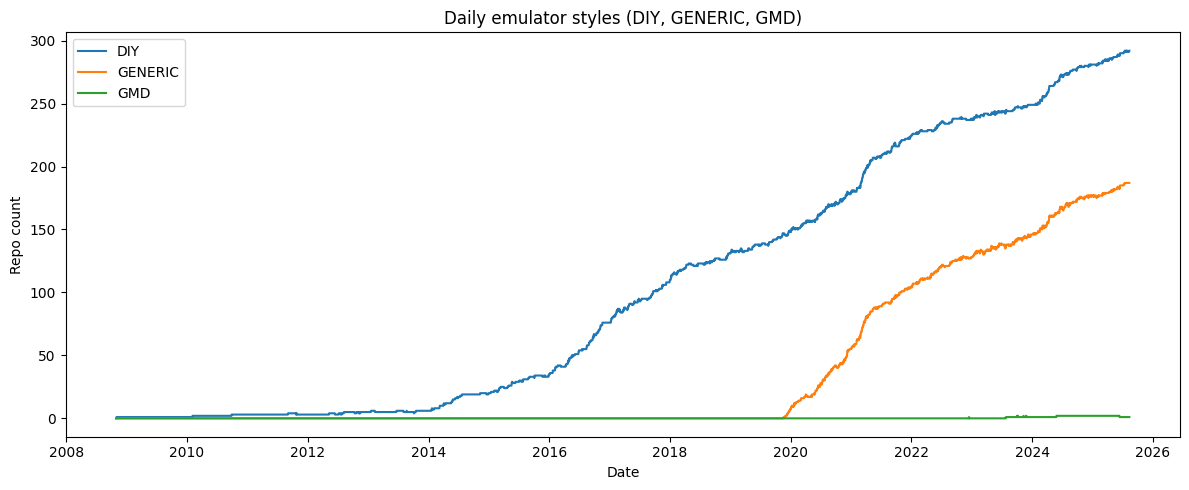

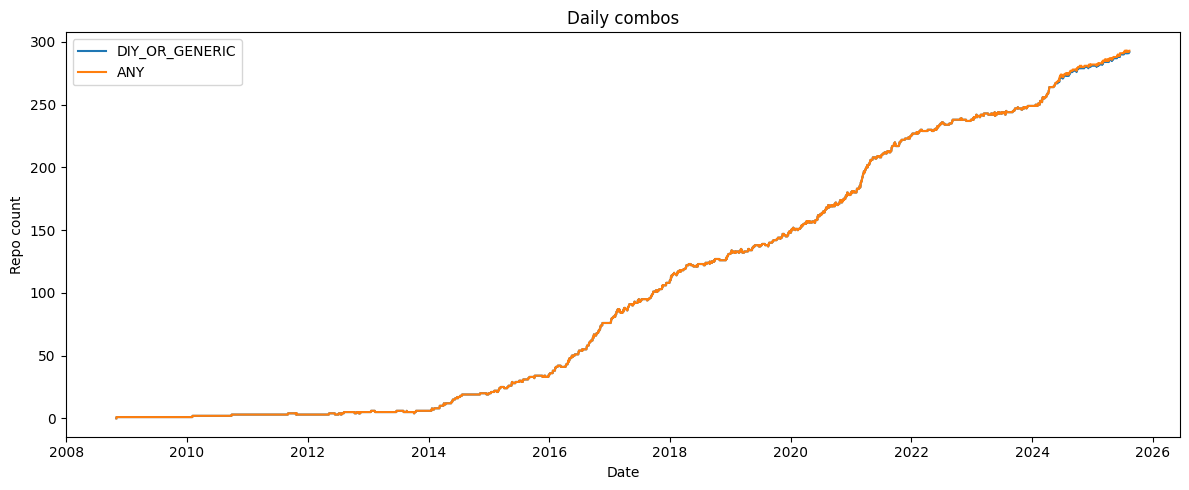

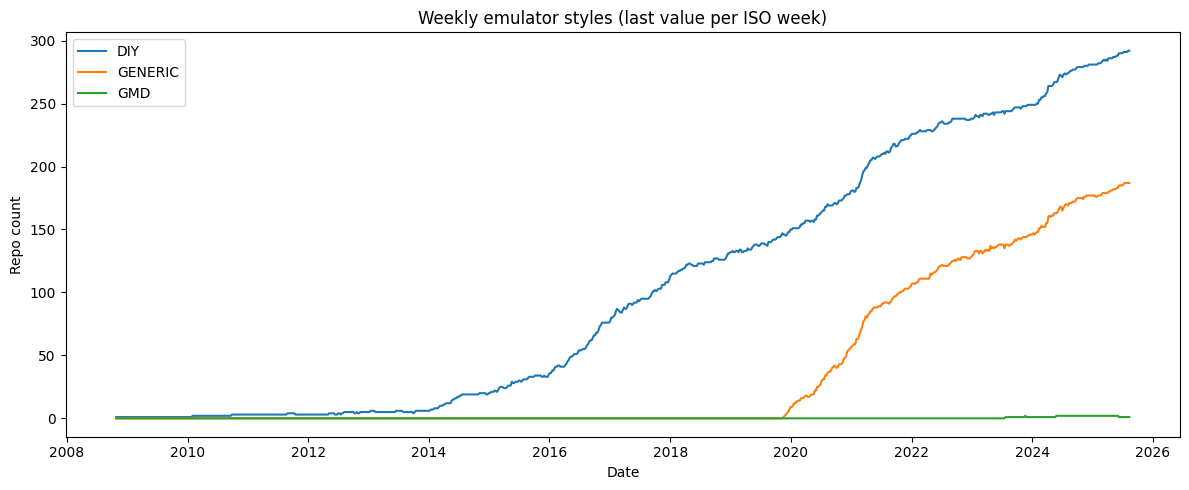

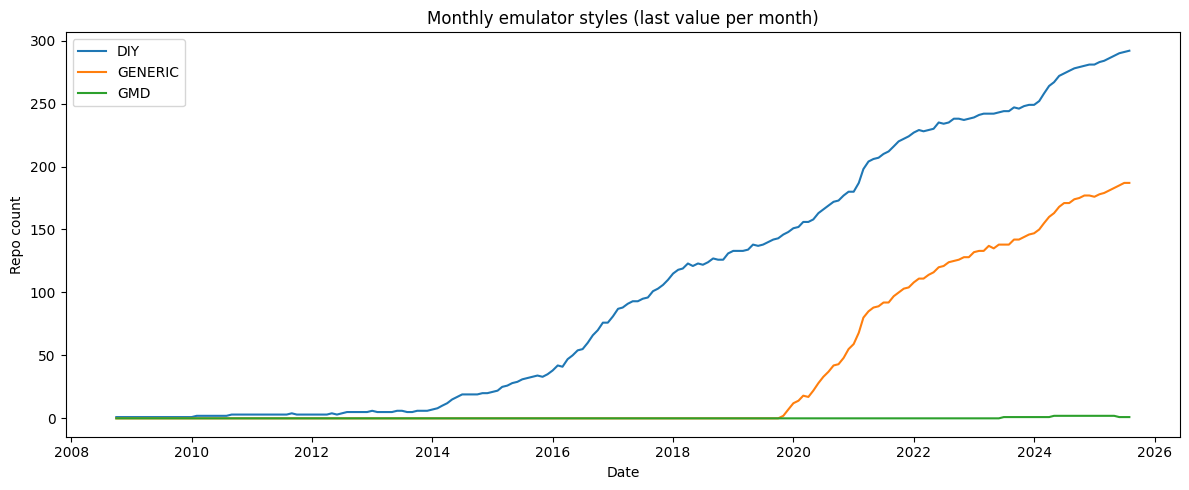

In [9]:
# build_emulator_style_timeline.py
# Creates group timelines of emulator styles across repos mined in Step 2 (V2).
# Input JSONs:  C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\mineV3.0\*.emulator_timeline.json
# Output files: C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\*.csv / *.json
# Optional charts: controlled via SHOW_PLOTS / SAVE_PLOTS

from __future__ import annotations
import json
import os
from pathlib import Path
from datetime import datetime, timedelta, timezone
from typing import Dict, List, Set, Tuple, Optional

# -----------------------------
# CONFIG — adjust if needed
# -----------------------------
BASE_FOLDER  = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2")
INPUT_MINE   = BASE_FOLDER / "mineV3.0"
OUTPUT_GROUP = BASE_FOLDER / "Group"

# Plot behavior
SHOW_PLOTS = True   # show interactive plots (you can manually save from the UI if you want)
SAVE_PLOTS = False  # also save PNGs to OUTPUT_GROUP (set True if you want files)

# Styles tracked (INTENT_GMD removed to match the miner)
STYLES = ["DIY", "GENERIC", "GMD"]

# Reasonable combined buckets
COMBOS = {
    "DIY_OR_GENERIC": {"DIY", "GENERIC"},
    "ANY": set(STYLES),
}

# -----------------------------
# Helpers
# -----------------------------
def parse_iso(dt: Optional[str]) -> Optional[datetime]:
    """Parse ISO 8601; handle 'Z' and missing timezone. Return naive UTC."""
    if not dt:
        return None
    s = dt.replace("Z", "+00:00")
    try:
        d = datetime.fromisoformat(s)
    except Exception:
        try:
            d = datetime.strptime(dt.split(".")[0].replace("Z",""), "%Y-%m-%dT%H:%M:%S")
        except Exception:
            return None
    if d.tzinfo is None:
        return d
    return d.astimezone(timezone.utc).replace(tzinfo=None)

def daterange(start: datetime, end_inclusive: datetime):
    cur = start
    one = timedelta(days=1)
    while cur <= end_inclusive:
        yield cur
        cur += one

def safe_mkdir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def load_repo_jsons(root: Path) -> List[Dict]:
    items = []
    if not root.exists():
        return items
    for p in root.glob("*.emulator_timeline.json"):
        try:
            with p.open("r", encoding="utf-8") as f:
                items.append(json.load(f))
        except Exception as e:
            print(f"[warn] could not parse {p.name}: {e}")
    return items

def label_to_datetime(label: str) -> datetime:
    """
    Accepts 'YYYY-MM-DD', 'YYYY-Www', or 'YYYY-MM' and returns a datetime.
    - Weeks return the Monday of that ISO week.
    - Months return the first day of the month.
    """
    # Full ISO date first
    try:
        return datetime.fromisoformat(label)
    except ValueError:
        pass

    # ISO week like '2008-W44'
    if "-W" in label:
        y, w = label.split("-W")
        return datetime.fromisocalendar(int(y), int(w), 1)  # Monday

    # Month like '2008-11'
    try:
        return datetime.strptime(label, "%Y-%m")
    except ValueError:
        pass

    raise ValueError(f"Unsupported date label: {label!r}")

# -----------------------------
# Core logic
# -----------------------------
def build_intervals_for_repo(repo_data: Dict) -> List[Tuple[datetime, Optional[datetime], Set[str]]]:
    """
    Turn a repo's change timeline into piecewise-constant intervals:
    [(start_date, end_date_exclusive_or_None, {styles})]
    """
    tl = repo_data.get("timeline", [])
    points: List[Tuple[datetime, Set[str]]] = []
    known = set(STYLES)  # guard against older outputs that might include INTENT_GMD

    for e in tl:
        d = parse_iso(e.get("date"))
        styles = set(e.get("styles") or [])
        # Drop any legacy labels (like INTENT_GMD) just in case
        styles = styles & known
        if d is not None:
            points.append((d, styles))

    points.sort(key=lambda x: x[0])
    intervals: List[Tuple[datetime, Optional[datetime], Set[str]]] = []
    for i, (start_d, styles) in enumerate(points):
        end_d = points[i + 1][0] if i + 1 < len(points) else None
        intervals.append((start_d, end_d, styles))
    return intervals

def compute_global_date_bounds(all_intervals: List[List[Tuple[datetime, Optional[datetime], Set[str]]]]) -> Tuple[Optional[datetime], Optional[datetime]]:
    min_d: Optional[datetime] = None
    max_d: Optional[datetime] = None
    for intervals in all_intervals:
        for (s, e, _styles) in intervals:
            if min_d is None or s < min_d:
                min_d = s
            candidate = (e - timedelta(days=1)) if e else s
            if max_d is None or candidate > max_d:
                max_d = candidate
    return min_d, max_d

def styles_active_on_date(intervals: List[Tuple[datetime, Optional[datetime], Set[str]]], day: datetime) -> Set[str]:
    for (s, e, st) in intervals:
        if s <= day and (e is None or day < e):
            return st
    return set()

def build_daily_counts(repo_jsons: List[Dict]) -> Dict[str, Dict[str, int]]:
    """
    Returns: dict[YYYY-MM-DD][metric] = count
    Metrics include each style in STYLES and combos in COMBOS.
    """
    repo_intervals = [build_intervals_for_repo(j) for j in repo_jsons]
    repo_intervals = [iv for iv in repo_intervals if iv]
    if not repo_intervals:
        return {}

    start_d, end_d = compute_global_date_bounds(repo_intervals)
    if start_d is None or end_d is None:
        return {}

    start_d = datetime(start_d.year, start_d.month, start_d.day)
    end_d   = datetime(end_d.year, end_d.month, end_d.day)

    out: Dict[str, Dict[str, int]] = {}
    for day in daterange(start_d, end_d):
        day_key = day.date().isoformat()
        counts = {s: 0 for s in STYLES}
        for combo_name in COMBOS.keys():
            counts[combo_name] = 0

        for iv in repo_intervals:
            st = styles_active_on_date(iv, day)
            for s in STYLES:
                if s in st:
                    counts[s] += 1
            for combo_name, combo_set in COMBOS.items():
                if st & combo_set:
                    counts[combo_name] += 1

        out[day_key] = counts
    return out

def write_csv(path: Path, rows: Dict[str, Dict[str, int]], columns: List[str]):
    with path.open("w", encoding="utf-8", newline="") as f:
        f.write(",".join(["date"] + columns) + "\n")
        for day in sorted(rows.keys()):
            vals = [str(rows[day].get(col, 0)) for col in columns]
            f.write(",".join([day] + vals) + "\n")

def resample_period(rows: Dict[str, Dict[str, int]], freq: str) -> Dict[str, Dict[str, int]]:
    """
    freq: 'W' (weekly, Mon-based) or 'M' (month end)
    We aggregate by the last value seen in the period (stepwise-constant series).
    """
    items = [(datetime.fromisoformat(k), v) for k, v in rows.items()]
    items.sort(key=lambda x: x[0])

    buckets: Dict[str, Dict[str, int]] = {}
    def period_key(d: datetime) -> str:
        if freq == "W":
            iso_year, iso_week, _ = d.isocalendar()
            return f"{iso_year}-W{iso_week:02d}"
        elif freq == "M":
            return f"{d.year}-{d.month:02d}"
        else:
            raise ValueError("Unsupported freq")

    last_seen: Dict[str, Tuple[datetime, Dict[str, int]]] = {}
    for d, vals in items:
        pk = period_key(d)
        last = last_seen.get(pk)
        if (last is None) or (d >= last[0]):
            last_seen[pk] = (d, vals)

    for pk, (_d, vals) in sorted(last_seen.items(), key=lambda x: x[0]):
        buckets[pk] = dict(vals)
    return buckets

def maybe_plot(rows: Dict[str, Dict[str, int]], title: str, series: List[str], save_path: Optional[Path] = None):
    try:
        import matplotlib.pyplot as plt
    except Exception as e:
        print(f"[info] Skipping plots (matplotlib not available): {e}")
        return
    dates = sorted(rows.keys())
    if not dates:
        print("[info] No data to plot.")
        return
    # robustly parse daily 'YYYY-MM-DD', weekly 'YYYY-Www', or monthly 'YYYY-MM'
    xs = [label_to_datetime(d) for d in dates]
    plt.figure(figsize=(12, 5))
    for name in series:
        ys = [rows[d].get(name, 0) for d in dates]
        plt.plot(xs, ys, label=name)
    plt.xlabel("Date")
    plt.ylabel("Repo count")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if SAVE_PLOTS and save_path is not None:
        plt.savefig(save_path)
        print(f"[ok] Saved {save_path}")
    if SHOW_PLOTS:
        # Show interactively; you can save from the UI if desired
        try:
            plt.show()
        except Exception:
            # Some headless environments will error; just close silently
            pass
    plt.close()

def main():
    safe_mkdir(OUTPUT_GROUP)

    repo_jsons = load_repo_jsons(INPUT_MINE)
    if not repo_jsons:
        print(f"[info] No mined JSONs found under: {INPUT_MINE}")
        return

    daily = build_daily_counts(repo_jsons)
    if not daily:
        print("[info] No timeline intervals found. Nothing to write.")
        return

    cols = STYLES + list(COMBOS.keys())

    # Write daily CSV
    daily_csv = OUTPUT_GROUP / "group_counts_daily.csv"
    write_csv(daily_csv, daily, cols)
    print(f"[ok] Wrote {daily_csv}")

    # Weekly (ISO) and Monthly
    weekly = resample_period(daily, "W")
    weekly_csv = OUTPUT_GROUP / "group_counts_weekly.csv"
    write_csv(weekly_csv, weekly, cols)
    print(f"[ok] Wrote {weekly_csv}")

    monthly = resample_period(daily, "M")
    monthly_csv = OUTPUT_GROUP / "group_counts_monthly.csv"
    write_csv(monthly_csv, monthly, cols)
    print(f"[ok] Wrote {monthly_csv}")

    # Metadata
    meta = {
        "base_folder": str(BASE_FOLDER),
        "input": str(INPUT_MINE),
        "output": str(OUTPUT_GROUP),
        "styles": STYLES,
        "combos": {k: sorted(list(v)) for k, v in COMBOS.items()},
        "date_range": {"first": min(daily.keys()), "last": max(daily.keys())},
        "files": {
            "daily_csv": str(daily_csv),
            "weekly_csv": str(weekly_csv),
            "monthly_csv": str(monthly_csv),
        },
    }
    meta_json = OUTPUT_GROUP / "group_counts_meta.json"
    with meta_json.open("w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)
    print(f"[ok] Wrote {meta_json}")

    # Plots
    maybe_plot(daily,   "Daily emulator styles (DIY, GENERIC, GMD)", STYLES,
               OUTPUT_GROUP / "group_counts_daily.png")
    maybe_plot(daily,   "Daily combos", list(COMBOS.keys()),
               OUTPUT_GROUP / "group_counts_daily_combos.png")
    maybe_plot(weekly,  "Weekly emulator styles (last value per ISO week)", STYLES,
               OUTPUT_GROUP / "group_counts_weekly.png")
    maybe_plot(monthly, "Monthly emulator styles (last value per month)", STYLES,
               OUTPUT_GROUP / "group_counts_monthly.png")

if __name__ == "__main__":
    main()


## State Machine

In [11]:
# summarize_emulator_styles_v3.py
# mineV3.0 summary:
# - Avg dwell time (days) for states: DIY, GENERIC, GMD, DIY+GENERIC
# - Most likely and second most likely next transition for each state
#
# Input:  C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\mineV3.0\*.emulator_timeline.json
# Output: C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\emulator_style_summary_v3.csv

from __future__ import annotations
import json
from pathlib import Path
from datetime import datetime, timezone
from typing import Dict, List, Set, Tuple, Optional
import csv

# -----------------------------
# Paths
# -----------------------------
BASE_FOLDER  = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2")
INPUT_MINE   = BASE_FOLDER / "mineV3.0"
OUTPUT_GROUP = BASE_FOLDER / "Group"
OUTPUT_CSV   = OUTPUT_GROUP / "emulator_style_summary_v3.csv"

# -----------------------------
# Canonical states (mutually exclusive)
# -----------------------------
STATE_LABELS = ["DIY", "GENERIC", "GMD", "DIY+GENERIC"]

def label_for_styles(st: Set[str]) -> Optional[str]:
    """Map a set of styles to one of our four canonical states, else None."""
    if st == {"DIY"}:
        return "DIY"
    if st == {"GENERIC"}:
        return "GENERIC"
    if st == {"GMD"}:
        return "GMD"
    if st == {"DIY", "GENERIC"}:
        return "DIY+GENERIC"
    # Ignore anything else (empty set or unexpected combos)
    return None

# -----------------------------
# Helpers
# -----------------------------
def safe_mkdir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def parse_iso(dt: Optional[str]) -> Optional[datetime]:
    """Parse ISO 8601; handle 'Z' and missing timezone. Return naive UTC."""
    if not dt:
        return None
    s = dt.replace("Z", "+00:00")
    try:
        d = datetime.fromisoformat(s)
    except Exception:
        try:
            d = datetime.strptime(dt.split(".")[0].replace("Z", ""), "%Y-%m-%dT%H:%M:%S")
        except Exception:
            return None
    if d.tzinfo is None:
        return d
    return d.astimezone(timezone.utc).replace(tzinfo=None)

def load_repo_jsons(root: Path) -> List[Dict]:
    items = []
    if not root.exists():
        return items
    for p in root.glob("*.emulator_timeline.json"):
        try:
            with p.open("r", encoding="utf-8") as f:
                items.append(json.load(f))
        except Exception as e:
            print(f"[warn] could not parse {p.name}: {e}")
    return items

def build_intervals_for_repo(repo_data: Dict) -> List[Tuple[datetime, Optional[datetime], Set[str]]]:
    """
    Return piecewise-constant intervals:
      [(start_date, end_date_exclusive_or_None, {styles})]
    Coalesce repeated consecutive style-sets.
    """
    tl = repo_data.get("timeline", [])
    points: List[Tuple[datetime, Set[str]]] = []
    for e in tl:
        d = parse_iso(e.get("date"))
        st = set(e.get("styles") or [])
        if d is not None:
            points.append((d, st))

    if not points:
        return []

    points.sort(key=lambda x: x[0])

    # Coalesce consecutive duplicates
    coalesced: List[Tuple[datetime, Set[str]]] = []
    for d, st in points:
        if not coalesced or st != coalesced[-1][1]:
            coalesced.append((d, st))
        # else exact duplicate set at later date: ignore

    intervals: List[Tuple[datetime, Optional[datetime], Set[str]]] = []
    for i, (start_d, st) in enumerate(coalesced):
        end_d = coalesced[i + 1][0] if i + 1 < len(coalesced) else None
        intervals.append((start_d, end_d, st))
    return intervals

# -----------------------------
# Metrics
# -----------------------------
def accumulate_dwell_and_transitions(
    intervals: List[Tuple[datetime, Optional[datetime], Set[str]]],
    dwell_days: Dict[str, List[float]],
    transitions: Dict[str, Dict[str, int]],
):
    """
    - Add dwell durations (days) for CLOSED intervals per canonical state.
    - Count transitions from state A to state B (where both A and B are canonical).
    """
    # Dwell
    for (s, e, st) in intervals:
        src = label_for_styles(st)
        if src is None:
            continue
        if e is None:
            # Open-ended final interval: exclude from dwell
            continue
        d_days = (e - s).days
        if d_days >= 0:
            dwell_days[src].append(float(d_days))

    # Transitions
    for i in range(len(intervals) - 1):
        s1, e1, st1 = intervals[i]
        s2, _,  st2 = intervals[i + 1]
        src = label_for_styles(st1)
        dst = label_for_styles(st2)
        if src is None or dst is None:
            continue
        transitions[src][dst] = transitions[src].get(dst, 0) + 1

def top_two_transitions(counts: Dict[str, int]) -> List[Tuple[str, float]]:
    """
    Return top two (state, pct) pairs based on counts. Percentages sum to 100% across all destinations.
    """
    total = sum(counts.values())
    if total == 0:
        return []
    # Sort by count desc, then by state name for stability
    items = sorted(counts.items(), key=lambda kv: (-kv[1], kv[0]))
    result = []
    for state, c in items[:2]:
        pct = 100.0 * c / total
        result.append((state, pct))
    return result

# -----------------------------
# Main
# -----------------------------
def main():
    safe_mkdir(OUTPUT_GROUP)

    repo_jsons = load_repo_jsons(INPUT_MINE)
    if not repo_jsons:
        print(f"[info] No mined JSONs found under: {INPUT_MINE}")
        # Write header only
        with OUTPUT_CSV.open("w", newline="", encoding="utf-8") as f:
            w = csv.writer(f)
            w.writerow([
                "state",
                "avg_dwell_days",
                "most_likely_next",
                "most_likely_next_pct",
                "second_most_likely_next",
                "second_most_likely_next_pct",
                "n_dwell_intervals",
                "n_outgoing_transitions"
            ])
        print(f"[ok] Wrote empty {OUTPUT_CSV}")
        return

    # Build intervals
    all_intervals = []
    for j in repo_jsons:
        iv = build_intervals_for_repo(j)
        if iv:
            all_intervals.append(iv)

    # Accumulators
    dwell_days: Dict[str, List[float]] = {s: [] for s in STATE_LABELS}
    transitions: Dict[str, Dict[str, int]] = {s: {} for s in STATE_LABELS}

    for iv in all_intervals:
        accumulate_dwell_and_transitions(iv, dwell_days, transitions)

    # Write summary CSV
    with OUTPUT_CSV.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow([
            "state",
            "avg_dwell_days",
            "most_likely_next",
            "most_likely_next_pct",
            "second_most_likely_next",
            "second_most_likely_next_pct",
            "n_dwell_intervals",
            "n_outgoing_transitions"
        ])

        for state in STATE_LABELS:
            dw = dwell_days[state]
            avg_dwell = (sum(dw) / len(dw)) if dw else 0.0
            out_counts = transitions[state]
            top2 = top_two_transitions(out_counts)
            ml_state, ml_pct = (top2[0][0], top2[0][1]) if len(top2) >= 1 else ("", 0.0)
            snd_state, snd_pct = (top2[1][0], top2[1][1]) if len(top2) >= 2 else ("", 0.0)

            w.writerow([
                state,
                f"{avg_dwell:.2f}",
                ml_state if not ml_state else f"{state} To {ml_state}",
                f"{ml_pct:.1f}%",
                snd_state if not snd_state else f"{state} To {snd_state}",
                f"{snd_pct:.1f}%",
                len(dw),
                sum(out_counts.values())
            ])

    print(f"[ok] Wrote {OUTPUT_CSV}")

if __name__ == "__main__":
    main()


[ok] Wrote C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\emulator_style_summary_v3.csv
